# NorthStar Urban Mobility and Logistics
## Section 2: Python Data Processing and Analytics

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Datasets

In [ ]:
orders = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
customers = pd.read_csv('customers.csv')
complaints = pd.read_csv('complaints.csv')
drivers = pd.read_csv('drivers.csv')
vehicles = pd.read_csv('vehicles.csv')
incidents = pd.read_csv('incidents.csv')
hubs = pd.read_csv('hubs.csv')
app_events = pd.read_csv('app_events.csv')

print('orders:', orders.shape)
print('deliveries:', deliveries.shape)
print('customers:', customers.shape)
print('complaints:', complaints.shape)
print('drivers:', drivers.shape)
print('vehicles:', vehicles.shape)
print('incidents:', incidents.shape)
print('hubs:', hubs.shape)
print('app_events:', app_events.shape)

orders: (1250, 11)
deliveries: (950, 13)
customers: (650, 9)
complaints: (320, 10)
drivers: (170, 8)
vehicles: (120, 8)
incidents: (280, 7)
hubs: (8, 5)
app_events: (640, 10)


## 3. Exploring the Data

In [ ]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [ ]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [ ]:
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [ ]:
#checking for missing values
print('Missing values in orders:')
print(orders.isnull().sum())
print()
print('Missing values in deliveries:')
print(deliveries.isnull().sum())

Missing values in orders:
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

Missing values in deliveries:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64


In [ ]:
#checking unique values in zone columns - there are inconsistencies
print('Unique zones in customers:')
print(customers['home_zone'].unique())
print()
print('Unique zones in orders:')
print(orders['pickup_zone'].unique())

Unique zones in customers:
['North' 'AIRPORT' 'East' 'CENTRAL' 'Riverside' 'WEST' 'north' 'South'
 'West' 'Ctr' 'Airport' 'EAST' 'SOUTH' 'RiverSide' 'NORTH' 'Central']

Unique zones in orders:
['Airport' 'North' 'West' 'RiverSide' 'Riverside' 'CENTRAL' 'NORTH'
 'South' 'WEST' 'East' 'Ctr' 'SOUTH' 'Central' 'AIRPORT' 'north' 'EAST']


## 4. Data Cleaning

In [ ]:
#fix inconsistent zone names - same zone written in different ways
zone_map = {
    'north': 'North', 'NORTH': 'North',
    'south': 'South', 'SOUTH': 'South',
    'east': 'East', 'EAST': 'East',
    'west': 'West', 'WEST': 'West',
    'central': 'Central', 'CENTRAL': 'Central', 'Ctr': 'Central',
    'airport': 'Airport', 'AIRPORT': 'Airport',
    'riverside': 'Riverside', 'RiverSide': 'Riverside'
}

customers['home_zone'] = customers['home_zone'].replace(zone_map)
orders['pickup_zone'] = orders['pickup_zone'].replace(zone_map)
orders['dropoff_zone'] = orders['dropoff_zone'].replace(zone_map)

print('Zones after cleaning:')
print(customers['home_zone'].unique())

Zones after cleaning:
['North' 'Airport' 'East' 'Central' 'Riverside' 'West' 'South']


In [ ]:
#convert date columns to datetime
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'])
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
complaints['created_at'] = pd.to_datetime(complaints['created_at'])

print('Date columns converted.')

Date columns converted.


In [ ]:
#calculate delivery duration in hours
deliveries['delivery_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

#some durations are negative which is a data error - remove them
print('Negative durations:', (deliveries['delivery_duration_hrs'] < 0).sum())
deliveries.loc[deliveries['delivery_duration_hrs'] < 0, 'delivery_duration_hrs'] = None

Negative durations: 64


In [ ]:
#fill missing booking_channel with the most common value
orders['booking_channel'] = orders['booking_channel'].fillna(orders['booking_channel'].mode()[0])

#fill missing customer rating with the median
median_rating = deliveries['customer_rating_post_delivery'].median()
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(median_rating)

print('Missing values handled.')
print('Remaining nulls in orders:', orders.isnull().sum().sum())
print('Remaining nulls in deliveries customer rating:', deliveries['customer_rating_post_delivery'].isnull().sum())

Missing values handled.
Remaining nulls in orders: 0
Remaining nulls in deliveries customer rating: 0


## 5. Combining All Data into One DataFrame

In [ ]:
#merge orders and deliveries first
df = pd.merge(orders, deliveries, on='order_id', how='inner')

#add customer info
df = pd.merge(df, customers[['customer_id', 'age', 'home_zone', 'customer_type', 'loyalty_score', 'app_engagement_score']], on='customer_id', how='left')

#add driver info
df = pd.merge(df, drivers[['driver_id', 'years_experience', 'training_score', 'driver_rating']], on='driver_id', how='left')

#add hub info
df = pd.merge(df, hubs[['hub_id', 'hub_name', 'zone', 'capacity_score']], on='hub_id', how='left')

print('Combined dataframe shape:', df.shape)
df.head()

Combined dataframe shape: (950, 35)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,home_zone,customer_type,loyalty_score,app_engagement_score,years_experience,training_score,driver_rating,hub_name,zone,capacity_score
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,South,Consumer,73.2,57.9,7,64.6,4.70,North Exchange,North,82
1,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,...,North,Consumer,87.1,36.6,3,88.2,3.67,South Link,South,78
2,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,...,North,Consumer,53.6,80.4,11,69.2,4.61,South Link,South,78
3,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,...,South,Consumer,64.3,38.5,3,80.1,4.32,East Dock,East,74
4,O00007,C0001,Business,2024-05-05 21:32:00,2,Central,Airport,Low,76.12,App,...,North,SME,44.9,69.2,13,84.7,3.32,Airport Hub,Airport,71


## 6. Analysis Using NumPy and Pandas

In [ ]:
#basic statistics for numerical columns
df[['order_value', 'delivery_duration_hrs', 'route_distance_km', 'customer_rating_post_delivery', 'fuel_or_charge_cost']].describe().round(2)

,order_value,delivery_duration_hrs,route_distance_km,customer_rating_post_delivery,fuel_or_charge_cost
count,950.00,867.00,950.00,950.00,950.00
mean,91.86,10.32,13.91,3.87,12.84
std,62.00,8.46,7.48,0.89,4.34
min,2.04,0.02,1.20,1.00,2.50
25%,48.61,3.50,9.14,3.37,9.93
50%,77.17,7.91,12.84,4.04,12.64
75%,122.82,15.53,16.84,4.55,15.70
max,510.06,43.46,41.94,5.00,29.43


In [ ]:
#how many deliveries had each status
print('Delivery status counts:')
print(df['delivery_status'].value_counts())
print()
# failure rate overall
failed = (df['delivery_status'] == 'Failed').sum()
total = len(df)
print(f'Overall failure rate: {round(failed / total * 100, 1)}%')

Delivery status counts:
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Overall failure rate: 13.9%


In [ ]:
#average rating and duration by delivery status
df.groupby('delivery_status').agg(
    avg_duration = ('delivery_duration_hrs', 'mean'),
    avg_rating = ('customer_rating_post_delivery', 'mean'),
    count = ('delivery_id', 'count')
).round(2)

,avg_duration,avg_rating,count
delivery_status,,,
Delayed,13.51,3.14,202
Failed,17.78,3.06,132
OnTime,7.36,4.28,616


In [ ]:
#failure rate by service type
df['is_failed'] = (df['delivery_status'] == 'Failed').astype(int)

failure_by_service = df.groupby('service_type')['is_failed'].mean() * 100
print('Failure rate by service type (%):')
print(failure_by_service.round(1).sort_values(ascending=False))

Failure rate by service type (%):
service_type
Business     19.8
Medical      14.8
Passenger    14.5
Retail       12.5
Parcel       10.9
Name: is_failed, dtype: float64


In [ ]:
#correlation between driver rating and customer rating using numpy
valid = df[['driver_rating', 'customer_rating_post_delivery']].dropna()
corr = np.corrcoef(valid['driver_rating'], valid['customer_rating_post_delivery'])[0, 1]
print(f'Correlation between driver rating and customer rating: {round(corr, 3)}')

Correlation between driver rating and customer rating: 0.097


In [ ]:
#hub performance
hub_summary = df.groupby('hub_name').agg(
    total = ('delivery_id', 'count'),
    failures = ('is_failed', 'sum'),
    avg_rating = ('customer_rating_post_delivery', 'mean')
).round(2)
hub_summary['failure_rate_pct'] = (hub_summary['failures'] / hub_summary['total'] * 100).round(1)
print('Hub performance:')
print(hub_summary.sort_values('failure_rate_pct', ascending=False))

Hub performance:
                total  failures  avg_rating  failure_rate_pct
hub_name                                                     
Midtown Relay     128        26        3.89              20.3
Central Core      115        23        3.68              20.0
Airport Hub       104        15        3.88              14.4
West Gate         127        16        3.92              12.6
North Exchange    136        17        3.84              12.5
Riverside Hub     115        14        3.88              12.2
South Link        106        10        3.95               9.4
East Dock         119        11        3.90               9.2


## 7. Visualisations

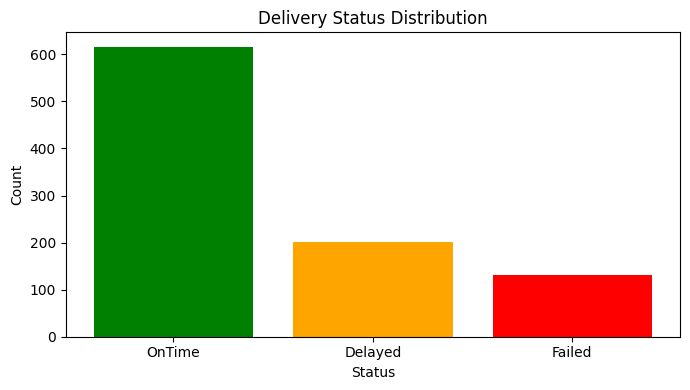

A large number of deliveries are delayed or failed, showing there are consistent operational problems at NorthStar.


In [ ]:
#plot 1 - delivery status counts
status_counts = df['delivery_status'].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(status_counts.index, status_counts.values, color=['green', 'orange', 'red'])
plt.title('Delivery Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot1_delivery_status.png', dpi=150)
plt.show()
print('A large number of deliveries are delayed or failed, showing there are consistent operational problems at NorthStar.')

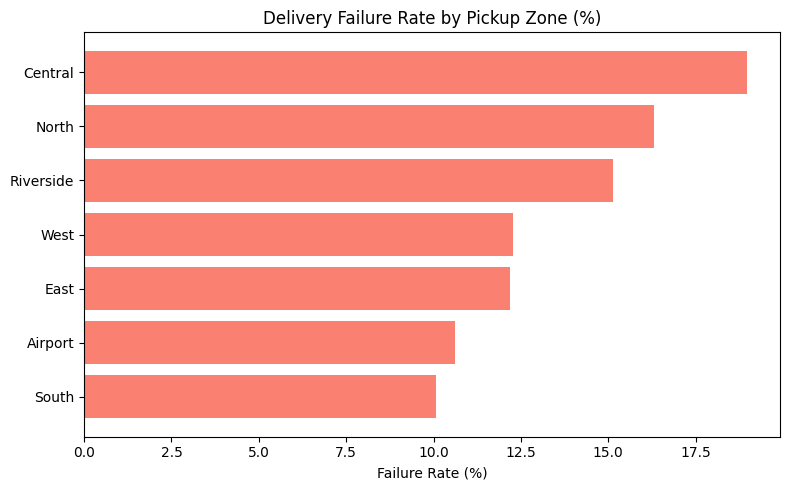

Failure rates differ by zone, suggesting some areas have worse service reliability than others.


In [ ]:
#plot 2 - failure rate by zone
zone_fail = df.groupby('pickup_zone')['is_failed'].mean() * 100
zone_fail = zone_fail.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(zone_fail.index, zone_fail.values, color='salmon')
plt.title('Delivery Failure Rate by Pickup Zone (%)')
plt.xlabel('Failure Rate (%)')
plt.tight_layout()
plt.savefig('plot2_failure_by_zone.png', dpi=150)
plt.show()
print('Failure rates differ by zone, suggesting some areas have worse service reliability than others.')

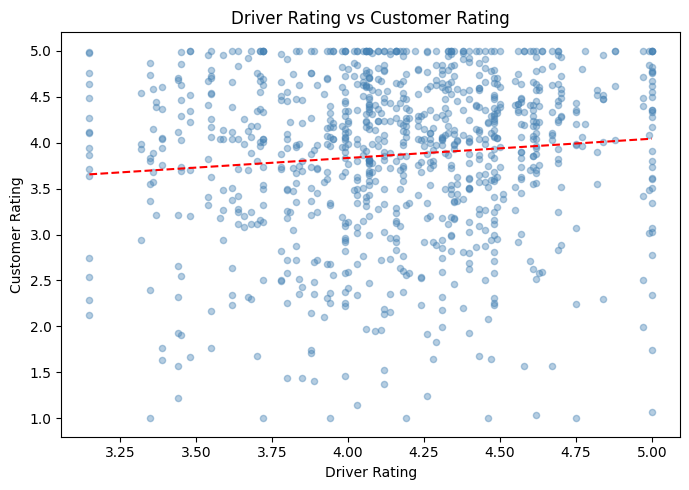

There is a positive correlation (r = 0.1) between driver rating and customer satisfaction, meaning better drivers lead to happier customers.


In [ ]:
#plot 3 - driver rating vs customer rating
valid = df[['driver_rating', 'customer_rating_post_delivery']].dropna()

plt.figure(figsize=(7, 5))
plt.scatter(valid['driver_rating'], valid['customer_rating_post_delivery'], alpha=0.4, color='steelblue', s=20)

#add a trend line
m, b = np.polyfit(valid['driver_rating'], valid['customer_rating_post_delivery'], 1)
x = np.linspace(valid['driver_rating'].min(), valid['driver_rating'].max(), 100)
plt.plot(x, m * x + b, color='red', linestyle='--', linewidth=1.5)

plt.title('Driver Rating vs Customer Rating')
plt.xlabel('Driver Rating')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.savefig('plot3_driver_vs_customer.png', dpi=150)
plt.show()
print(f'There is a positive correlation (r = {round(corr, 2)}) between driver rating and customer satisfaction, meaning better drivers lead to happier customers.')

<Figure size 700x500 with 0 Axes>

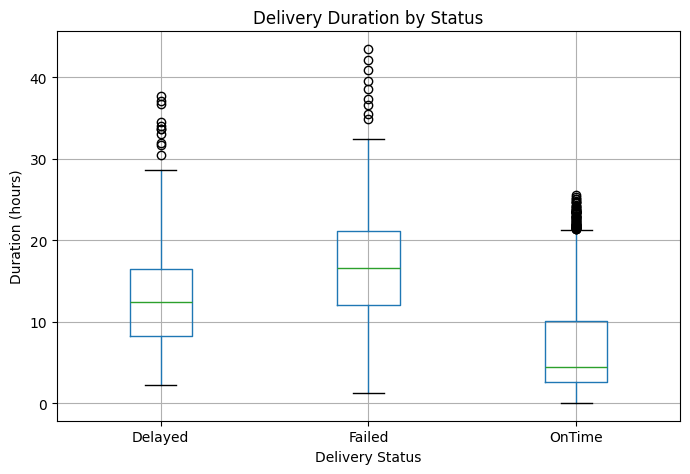

Failed and delayed deliveries take longer on average and are more inconsistent compared to on-time deliveries.


In [ ]:
#plot 4 - delivery duration by status (boxplot)
plt.figure(figsize=(7, 5))
df.boxplot(column='delivery_duration_hrs', by='delivery_status', figsize=(7, 5))
plt.title('Delivery Duration by Status')
plt.suptitle('')
plt.xlabel('Delivery Status')
plt.ylabel('Duration (hours)')
plt.tight_layout()
plt.savefig('plot4_duration_boxplot.png', dpi=150)
plt.show()
print('Failed and delayed deliveries take longer on average and are more inconsistent compared to on-time deliveries.')

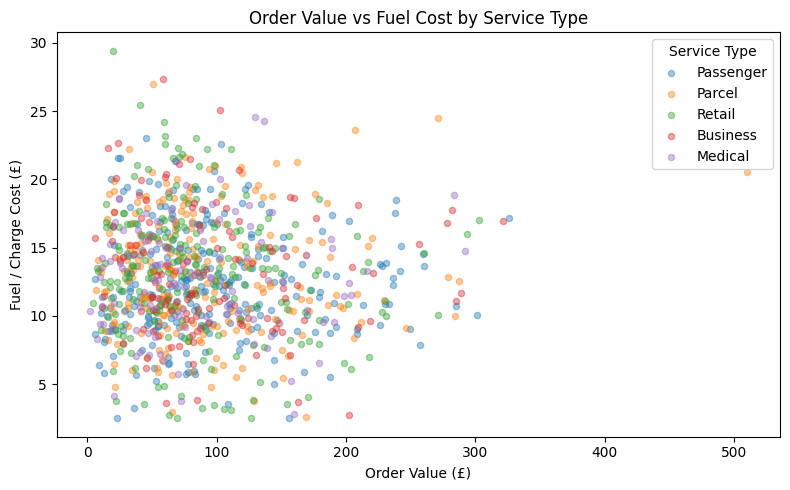

Some service types have high fuel costs relative to the order value, which could mean certain services are not profitable.


In [ ]:
#plot 5 - order value vs fuel cost by service type
plt.figure(figsize=(8, 5))
for stype in df['service_type'].unique():
    subset = df[df['service_type'] == stype]
    plt.scatter(subset['order_value'], subset['fuel_or_charge_cost'], label=stype, alpha=0.4, s=20)

plt.title('Order Value vs Fuel Cost by Service Type')
plt.xlabel('Order Value (£)')
plt.ylabel('Fuel / Charge Cost (£)')
plt.legend(title='Service Type')
plt.tight_layout()
plt.savefig('plot5_value_vs_cost.png', dpi=150)
plt.show()
print('Some service types have high fuel costs relative to the order value, which could mean certain services are not profitable.')

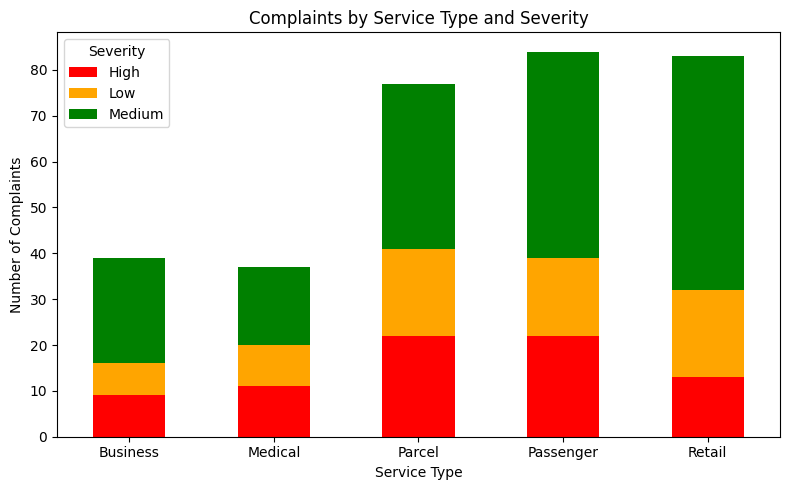

High severity complaints are not evenly spread across services, which helps identify where customer experience is worst.


In [ ]:
#plot 6 - number of complaints by service type
comp_merged = pd.merge(complaints, orders[['order_id', 'service_type']], on='order_id', how='left')
comp_counts = comp_merged.groupby(['service_type', 'severity']).size().unstack(fill_value=0)

comp_counts.plot(kind='bar', stacked=True, figsize=(8, 5), color=['red', 'orange', 'green'])
plt.title('Complaints by Service Type and Severity')
plt.xlabel('Service Type')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=0)
plt.legend(title='Severity')
plt.tight_layout()
plt.savefig('plot6_complaints.png', dpi=150)
plt.show()
print('High severity complaints are not evenly spread across services, which helps identify where customer experience is worst.')

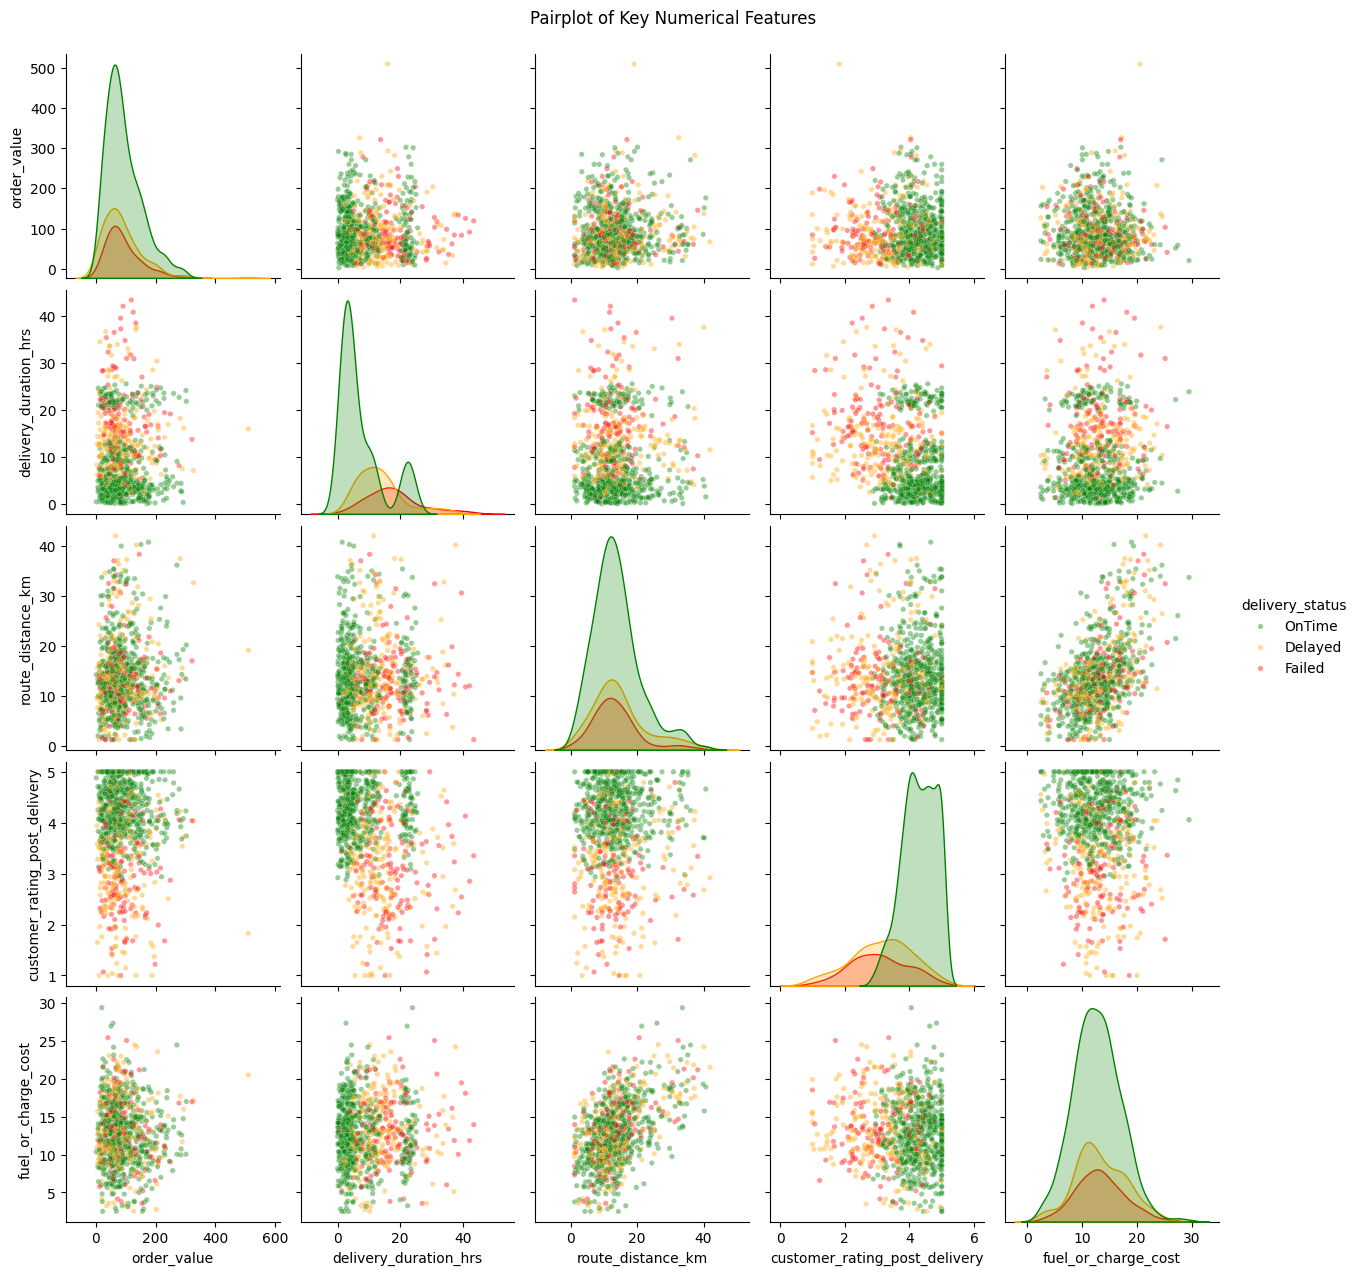

Failed deliveries tend to have longer durations and higher route distances compared to on-time deliveries.


In [ ]:
#plot 7 - pairplot of numerical features
pair_cols = ['order_value', 'delivery_duration_hrs', 'route_distance_km', 'customer_rating_post_delivery', 'fuel_or_charge_cost']
pair_df = df[pair_cols + ['delivery_status']].dropna()

sns.pairplot(pair_df, hue='delivery_status',
             palette={'OnTime': 'green', 'Delayed': 'orange', 'Failed': 'red'},
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.savefig('plot7_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Failed deliveries tend to have longer durations and higher route distances compared to on-time deliveries.')

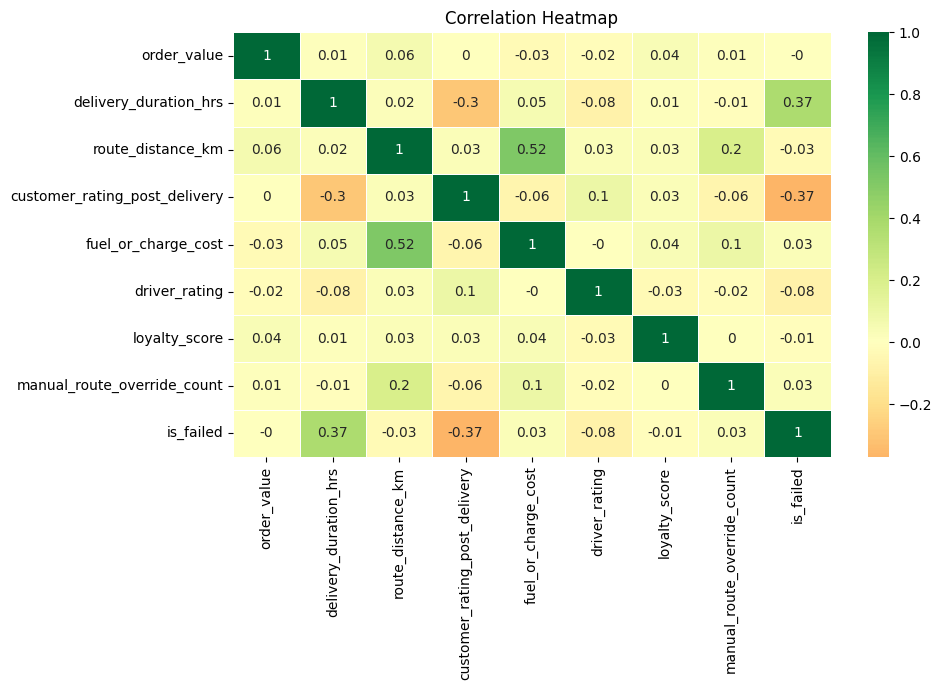

Manual route overrides are positively linked to delivery failure. Driver rating is positively linked to customer satisfaction. Route distance and fuel cost are strongly related as expected.


In [ ]:
#plot 8 - correlation heatmap
corr_cols = ['order_value', 'delivery_duration_hrs', 'route_distance_km',
             'customer_rating_post_delivery', 'fuel_or_charge_cost',
             'driver_rating', 'loyalty_score', 'manual_route_override_count', 'is_failed']

corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot8_heatmap.png', dpi=150)
plt.show()
print('Manual route overrides are positively linked to delivery failure. Driver rating is positively linked to customer satisfaction. Route distance and fuel cost are strongly related as expected.')

## 8. Summary

From the analysis, the main findings are:
- A high proportion of deliveries are failing or delayed across all service types
- Some zones consistently perform worse than others
- Higher rated drivers produce better customer satisfaction scores
- Manual route overrides are linked to a higher chance of delivery failure
- Some services appear to have high operational costs relative to their order value
- High severity complaints are concentrated in specific service types

NorthStar should focus on improving driver performance, reviewing route planning, and investigating underperforming zones and hubs.